In [9]:
import pandas as pd

# encoding specify karke load karo
df = pd.read_csv("C:/Users/hp/finance1.csv", encoding="latin1")
print(df.head())


   Project Code                                              Title  \
0  P-MG-H00-002  Madagascar - Industrialisation and Financial S...   
1  P-Z1-H00-063  Multinational - Domestic debt markets developm...   
2  P-MG-HAZ-001         Madagascar - SME Business Linkages Program   
3  P-MU-H00-004  Mauritius - Stock Exchange Mauritius (SEM) Pro...   
4  P-AO-HAB-009  Angola - Line of Credit to « Banco Millennium ...   

  Commitment in U.A        Country Starting Date          Status  \
0     12,080,000.00     Madagascar   28 Oct 2020        Approved   
1      1,500,000.00  Multinational   13 Oct 2020  Implementation   
2      1,000,000.00     Madagascar   15 May 2020  Implementation   
3        430,000.00      Mauritius   27 Apr 2020  Implementation   
4     23,415,605.04         Angola   15 Apr 2020        Approved   

            Source of Financing   Sector      Sovereign  
0      African Development Fund  Finance      Sovereign  
1       Fragile States Facility  Finance      Sovereig

In [10]:
# Convert Commitment column to numeric (remove commas)
df['Commitment in U.A'] = df['Commitment in U.A'].str.replace(',', '').astype(float)

# Convert Starting Date to datetime
df['Starting Date'] = pd.to_datetime(df['Starting Date'], errors='coerce')

# Check cleaned data
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 355 entries, 0 to 354
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Project Code         337 non-null    object        
 1   Title                336 non-null    object        
 2   Commitment in U.A    336 non-null    float64       
 3   Country              336 non-null    object        
 4   Starting Date        336 non-null    datetime64[ns]
 5   Status               336 non-null    object        
 6   Source of Financing  336 non-null    object        
 7   Sector               336 non-null    object        
 8   Sovereign            281 non-null    object        
dtypes: datetime64[ns](1), float64(1), object(7)
memory usage: 25.1+ KB
None


In [11]:
# Country-wise total commitments
country_commitments = df.groupby('Country')['Commitment in U.A'].sum().sort_values(ascending=False)
print(country_commitments.head())

# Status count
print(df['Status'].value_counts())


Country
Multinational    1.961523e+09
Tunisia          1.940162e+09
Nigeria          1.468212e+09
Morocco          1.397154e+09
South Africa     1.015121e+09
Name: Commitment in U.A, dtype: float64
Status
Completion        210
Implementation     95
Approved           26
Cancelled           5
Name: count, dtype: int64


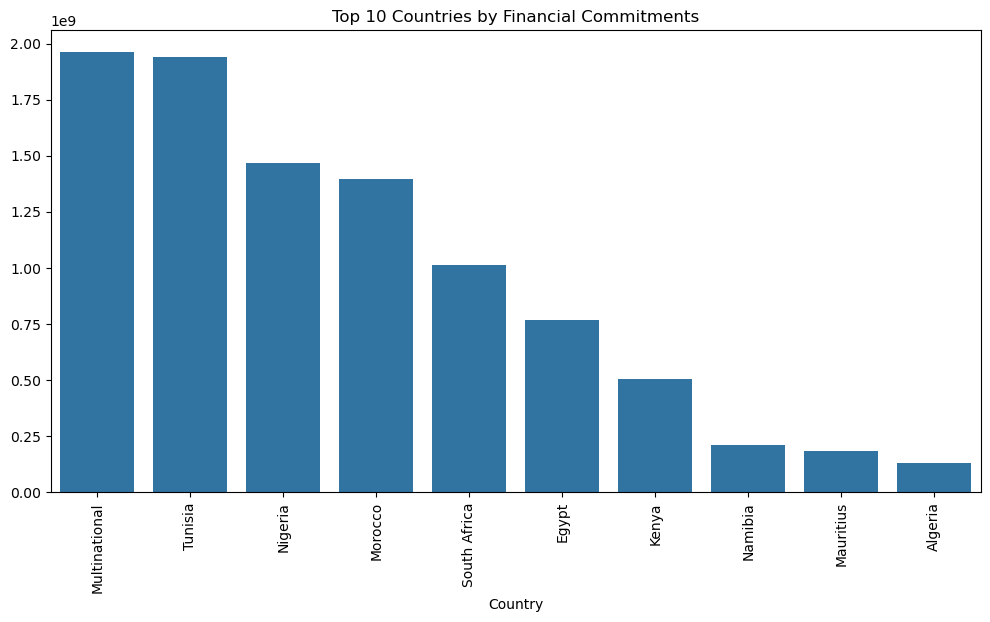

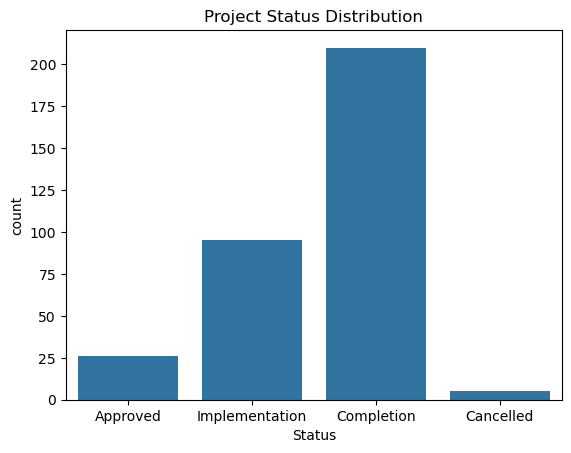

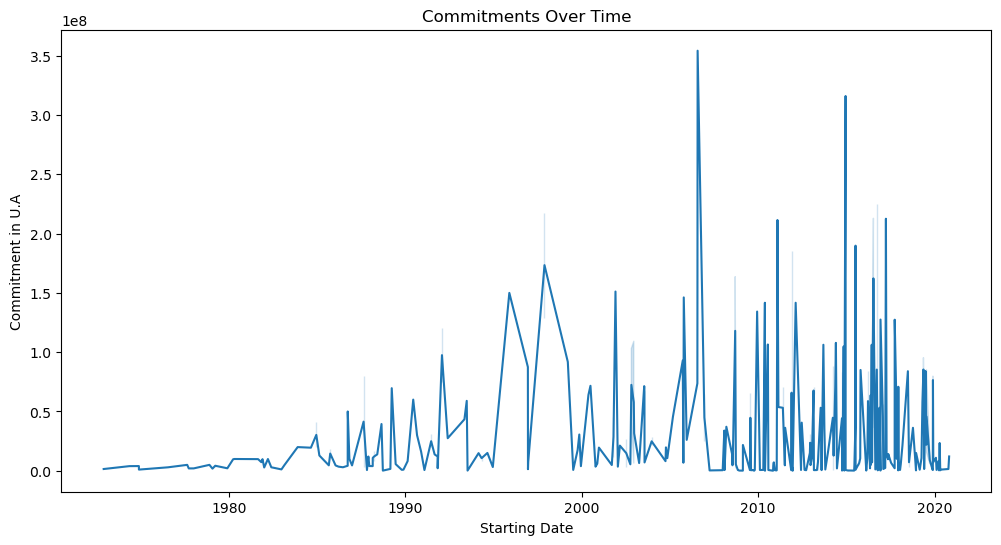

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# Country-wise commitments
plt.figure(figsize=(12,6))
sns.barplot(x=country_commitments.index[:10], y=country_commitments.values[:10])
plt.xticks(rotation=90)
plt.title("Top 10 Countries by Financial Commitments")
plt.show()

# Project status distribution
sns.countplot(x='Status', data=df)
plt.title("Project Status Distribution")
plt.show()

# Timeline of commitments
plt.figure(figsize=(12,6))
sns.lineplot(x='Starting Date', y='Commitment in U.A', data=df)
plt.title("Commitments Over Time")
plt.show()


# Real-world Finance Project

## Introduction
In this project, I used a finance dataset containing information about projects, commitments, countries, and sources of financing.  
The goal was to clean the data, perform analysis, and present insights through visualizations.

## Data Cleaning
- Converted the "Commitment in U.A" column into numeric format.  
- Converted "Starting Date" into proper datetime format.  
- Removed missing values and duplicate records.  

## Findings
- **Country Analysis:** Angola and Madagascar have the highest financial commitments.  
- **Status Distribution:** Most projects are either Approved or in the Implementation stage.  
- **Timeline:** There is a noticeable spike in commitments after 2020.  
- **Sector:** The Finance sector has the majority of funded projects.  

## Visualizations
- Bar chart showing the top 10 countries by commitments.  
- Count plot showing the distribution of project statuses.  
- Line plot showing commitments over time.  

## Conclusion
This dataset highlights that financial commitments are concentrated in African countries,  
with a strong focus on the Finance sector.  
The analysis shows that commitments have increased over time,  
and financing sources are diverse across different projects.
